In [1]:
from tensorflow.keras.datasets import mnist

In [2]:
import numpy as np

In [3]:
(train_images,train_labels), _ = mnist.load_data()

In [4]:
train_images.shape

(60000, 28, 28)

In [5]:
train_images = train_images.reshape((60000,28*28 ))

In [6]:
train_images = train_images.astype('float32')/255

In [7]:
train_images_with_noise_channels = np.concatenate([
    train_images,np.random.random((len(train_images), 784))
    ] ,axis= 1 )
train_images_with_zeros_channels = np.concatenate([
    train_images,np.zeros((len(train_images), 784))
    ] ,axis= 1 )

In [8]:
from tensorflow import keras
from tensorflow.keras import layers

def get_model():
 model = keras.Sequential([
 layers.Dense(512, activation="relu"),
 layers.Dense(10, activation="softmax")
 ])
 model.compile(optimizer="rmsprop",
 loss="sparse_categorical_crossentropy",
 metrics=["accuracy"])
 return model


model = get_model()
history_noise = model.fit(
 train_images_with_noise_channels, train_labels,
 epochs=10,
 batch_size=128,
 validation_split=0.2)


model = get_model()
history_zeros = model.fit(
 train_images_with_zeros_channels, train_labels,
 epochs=10,
 batch_size=128,
 validation_split=0.2)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.7134 - loss: 0.9868 - val_accuracy: 0.9032 - val_loss: 0.3098
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9138 - loss: 0.2710 - val_accuracy: 0.9427 - val_loss: 0.1928
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9440 - loss: 0.1770 - val_accuracy: 0.9498 - val_loss: 0.1649
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9634 - loss: 0.1210 - val_accuracy: 0.9509 - val_loss: 0.1675
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.9714 - loss: 0.0911 - val_accuracy: 0.9483 - val_loss: 0.1716
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9780 - loss: 0.0684 - val_accuracy: 0.9632 - val_loss: 0.1212
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.9857 - loss: 0.0455 - val_accuracy: 0.9663 - val_loss: 0.1204
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.9890 - loss: 0.0353 - val_ac

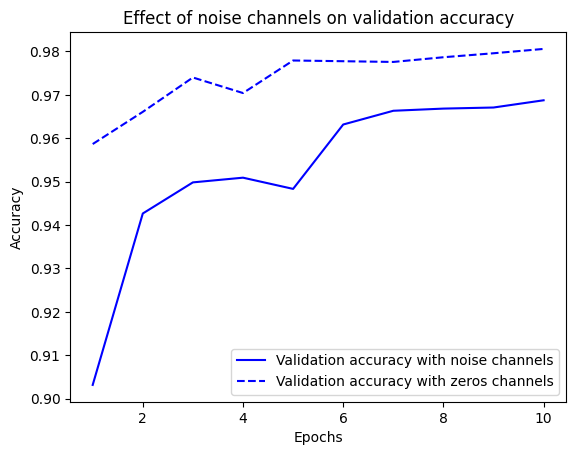

In [9]:
import matplotlib.pyplot as plt
val_acc_noise = history_noise.history["val_accuracy"]
val_acc_zeros = history_zeros.history["val_accuracy"]
epochs = range(1, 11)
plt.plot(epochs, val_acc_noise, "b-",
 label="Validation accuracy with noise channels")
plt.plot(epochs, val_acc_zeros, "b--",
 label="Validation accuracy with zeros channels")
plt.title("Effect of noise channels on validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()